# Exploratory Data Analysis: Togo (Dapaong)
## Solar Radiation Data Analysis

This notebook performs comprehensive EDA on solar radiation data from Togo-Dapaong.

**Analysis includes:**
- Summary statistics and missing value analysis
- Outlier detection using Z-scores
- Data cleaning and preparation
- Time series analysis
- Correlation analysis
- Wind analysis
- Temperature and humidity relationships

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Load the dataset (robust path detection)
import os

# Set country and probable filenames
country = "togo"
possible_filenames = [
    f"./data/{country}-dapaong_qc.csv",
    f"../data/{country}-dapaong_qc.csv",
    f"data/{country}-dapaong_qc.csv",
    f"./data/{country}_dapaong_qc.csv",
    f"./data/{country}-dapaong.csv",
]

data_path = None
for p in possible_filenames:
    if os.path.exists(p):
        data_path = p
        break

# If not found, try listing the data directories to help debugging
if data_path is None:
    data_dirs = ['./data', '../data', 'data']
    found_files = []
    for d in data_dirs:
        if os.path.isdir(d):
            for f in os.listdir(d):
                found_files.append(os.path.join(d, f))
    raise FileNotFoundError(
        f"Could not find a data file for '{country}'.\nTried: {possible_filenames}\n\nFiles found in data directories:\n" + "\n".join(found_files)
    )

# Read file header to check for Timestamp column and choose parse options
_header = pd.read_csv(data_path, nrows=0)
parse_dates = ['Timestamp'] if 'Timestamp' in _header.columns else []

# Load with parsing and safe coercion
df = pd.read_csv(data_path, parse_dates=parse_dates, dayfirst=False, low_memory=False)
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

print(f"Loaded data from: {data_path}")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\n" + "="*50)
print("First few rows:")
df.head()


Loaded data from: ./data/togo-dapaong_qc.csv
Dataset shape: (525600, 19)

Columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']

First few rows:


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


## 1. Summary Statistics & Missing Value Report

In [3]:
# Generate summary statistics
print("Summary Statistics for Numeric Columns:")
print("="*80)
summary = df.describe()
summary

Summary Statistics for Numeric Columns:


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


In [4]:
# Missing values analysis
missing_count = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Percentage', ascending=False)

print("\nMissing Values Report:")
print("="*50)
print(missing_df[missing_df['Missing_Count'] > 0])

# Identify columns with >5% missing values
high_missing = missing_df[missing_df['Missing_Percentage'] > 5]
if len(high_missing) > 0:
    print(f"\n⚠️ Columns with >5% missing values:")
    print(high_missing)
else:
    print("\n✅ No columns have >5% missing values")


Missing Values Report:
          Missing_Count  Missing_Percentage
Comments         525600               100.0

⚠️ Columns with >5% missing values:
          Missing_Count  Missing_Percentage
Comments         525600               100.0


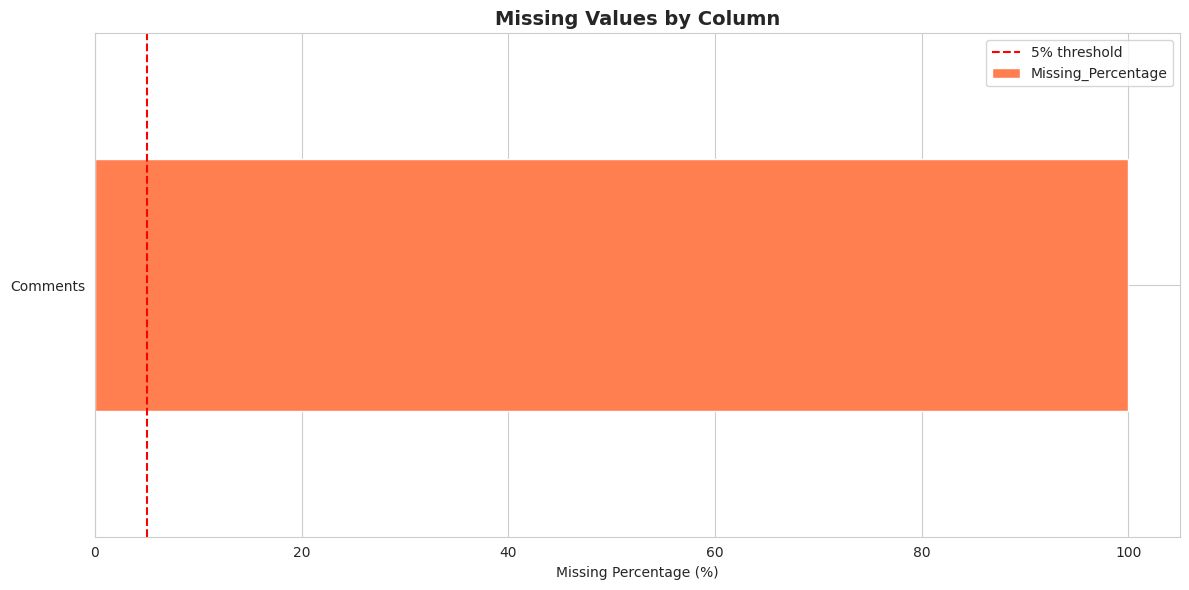

In [5]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_data = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage')

if len(missing_data) > 0:
    missing_data['Missing_Percentage'].plot(kind='barh', color='coral', ax=ax)
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    ax.axvline(x=5, color='red', linestyle='--', label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to visualize")

## 2. Outlier Detection & Data Cleaning

In [6]:
# Define key columns for outlier detection
key_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Compute Z-scores and flag outliers
def detect_outliers(df, columns, threshold=3):
    """
    Detect outliers using Z-score method
    """
    outlier_info = {}
    
    for col in columns:
        if col in df.columns:
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            outliers = (z_scores > threshold).sum()
            outlier_pct = (outliers / len(df)) * 100
            outlier_info[col] = {
                'count': outliers,
                'percentage': outlier_pct
            }
    
    return pd.DataFrame(outlier_info).T

outlier_report = detect_outliers(df, key_columns)
print("Outlier Detection Report (|Z| > 3):")
print("="*50)
print(outlier_report)

Outlier Detection Report (|Z| > 3):
         count  percentage
GHI      305.0    0.058029
DNI     1062.0    0.202055
DHI     3415.0    0.649734
ModA     137.0    0.026065
ModB     206.0    0.039193
WS      3510.0    0.667808
WSgust  3915.0    0.744863


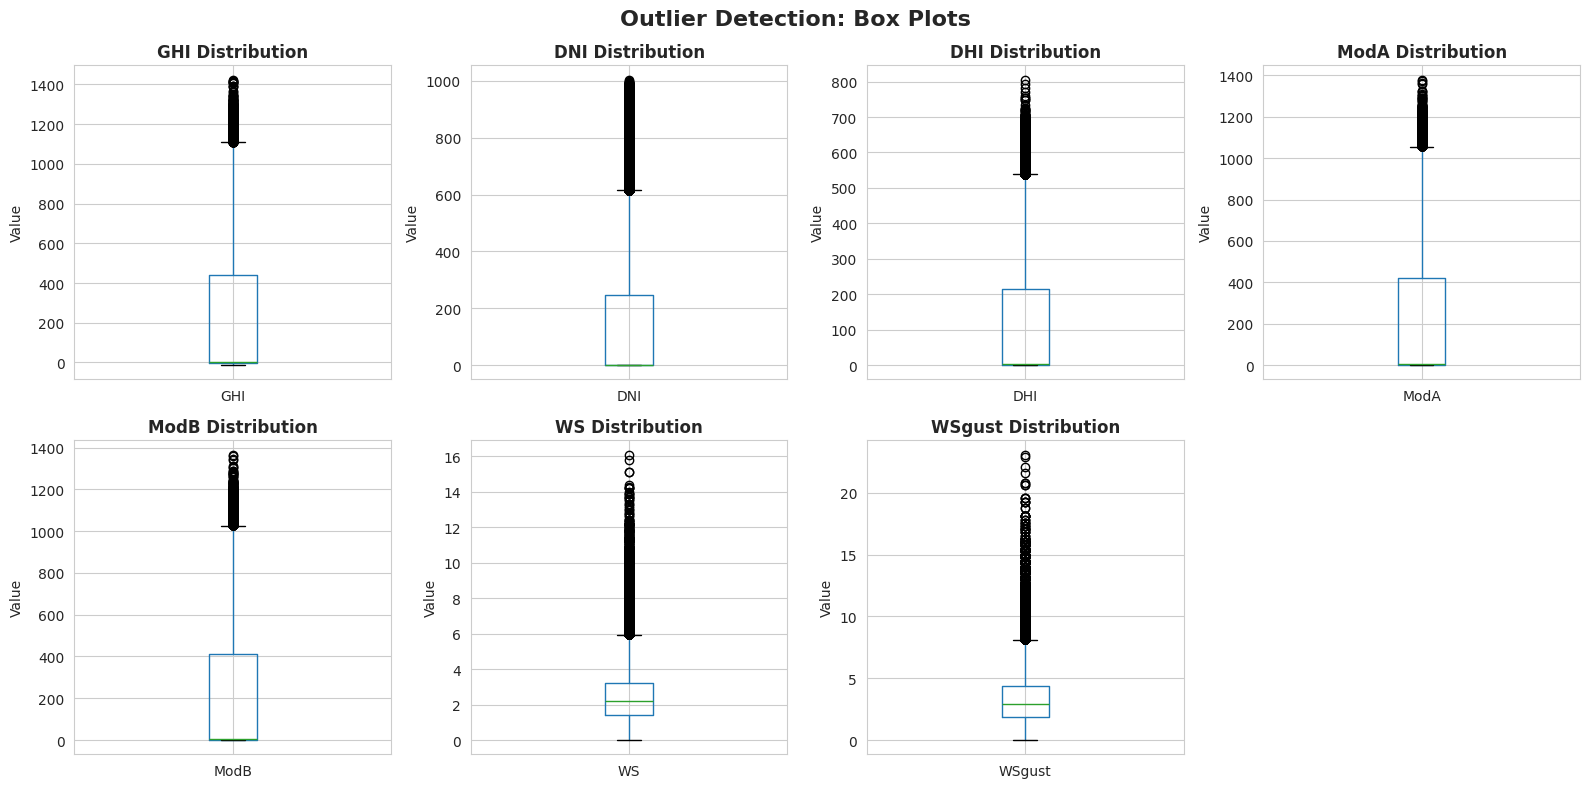

In [7]:
# Visualize outliers using box plots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(key_columns):
    if col in df.columns:
        df.boxplot(column=col, ax=axes[idx])
        axes[idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[idx].set_ylabel('Value')

# Hide unused subplot
axes[-1].axis('off')

plt.suptitle('Outlier Detection: Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Data cleaning
df_clean = df.copy()

print("Data Cleaning Steps:")
print("="*50)
print(f"Original shape: {df_clean.shape}")

# 1. Handle missing values in key columns
for col in key_columns:
    if col in df_clean.columns:
        missing_before = df_clean[col].isna().sum()
        if missing_before > 0:
            # Impute with median
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"✓ Imputed {missing_before} missing values in {col} with median")

# 2. Remove extreme outliers (optional - keeping for now but flagging)
df_clean['has_outlier'] = False
for col in key_columns:
    if col in df_clean.columns:
        z_scores = np.abs(stats.zscore(df_clean[col]))
        df_clean.loc[z_scores > 3, 'has_outlier'] = True

outlier_count = df_clean['has_outlier'].sum()
print(f"\n✓ Flagged {outlier_count} rows with outliers ({(outlier_count/len(df_clean)*100):.2f}%)")

# 3. Convert timestamp to datetime if exists
if 'Timestamp' in df_clean.columns:
    df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
    print("✓ Converted Timestamp to datetime format")

print(f"\nCleaned shape: {df_clean.shape}")
print("\n✅ Data cleaning completed")

Data Cleaning Steps:
Original shape: (525600, 19)

✓ Flagged 9251 rows with outliers (1.76%)
✓ Converted Timestamp to datetime format

Cleaned shape: (525600, 20)

✅ Data cleaning completed

✓ Flagged 9251 rows with outliers (1.76%)
✓ Converted Timestamp to datetime format

Cleaned shape: (525600, 20)

✅ Data cleaning completed


In [9]:
# Export cleaned data (ensure target directory exists)
import os
from pathlib import Path

# Determine project data directory robustly
# Prefer project_root/data relative to current working directory
project_root = Path.cwd()
# If running from notebooks/ folder, parent is project root
if project_root.name == 'notebooks':
    project_root = project_root.parent

output_dir = project_root / 'data'
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / f"{country}_clean.csv"
# Write CSV
df_clean.to_csv(output_path.as_posix(), index=False)
print(f"✅ Cleaned data exported to: {output_path}")


✅ Cleaned data exported to: /home/aj7479/Desktop/solar-challenge-week1/data/togo_clean.csv


## 3. Time Series Analysis

In [10]:
# Prepare for time series analysis
if 'Timestamp' in df_clean.columns:
    df_clean['Hour'] = df_clean['Timestamp'].dt.hour
    df_clean['Month'] = df_clean['Timestamp'].dt.month
    df_clean['Date'] = df_clean['Timestamp'].dt.date
    print("✅ Time-based features extracted")

✅ Time-based features extracted


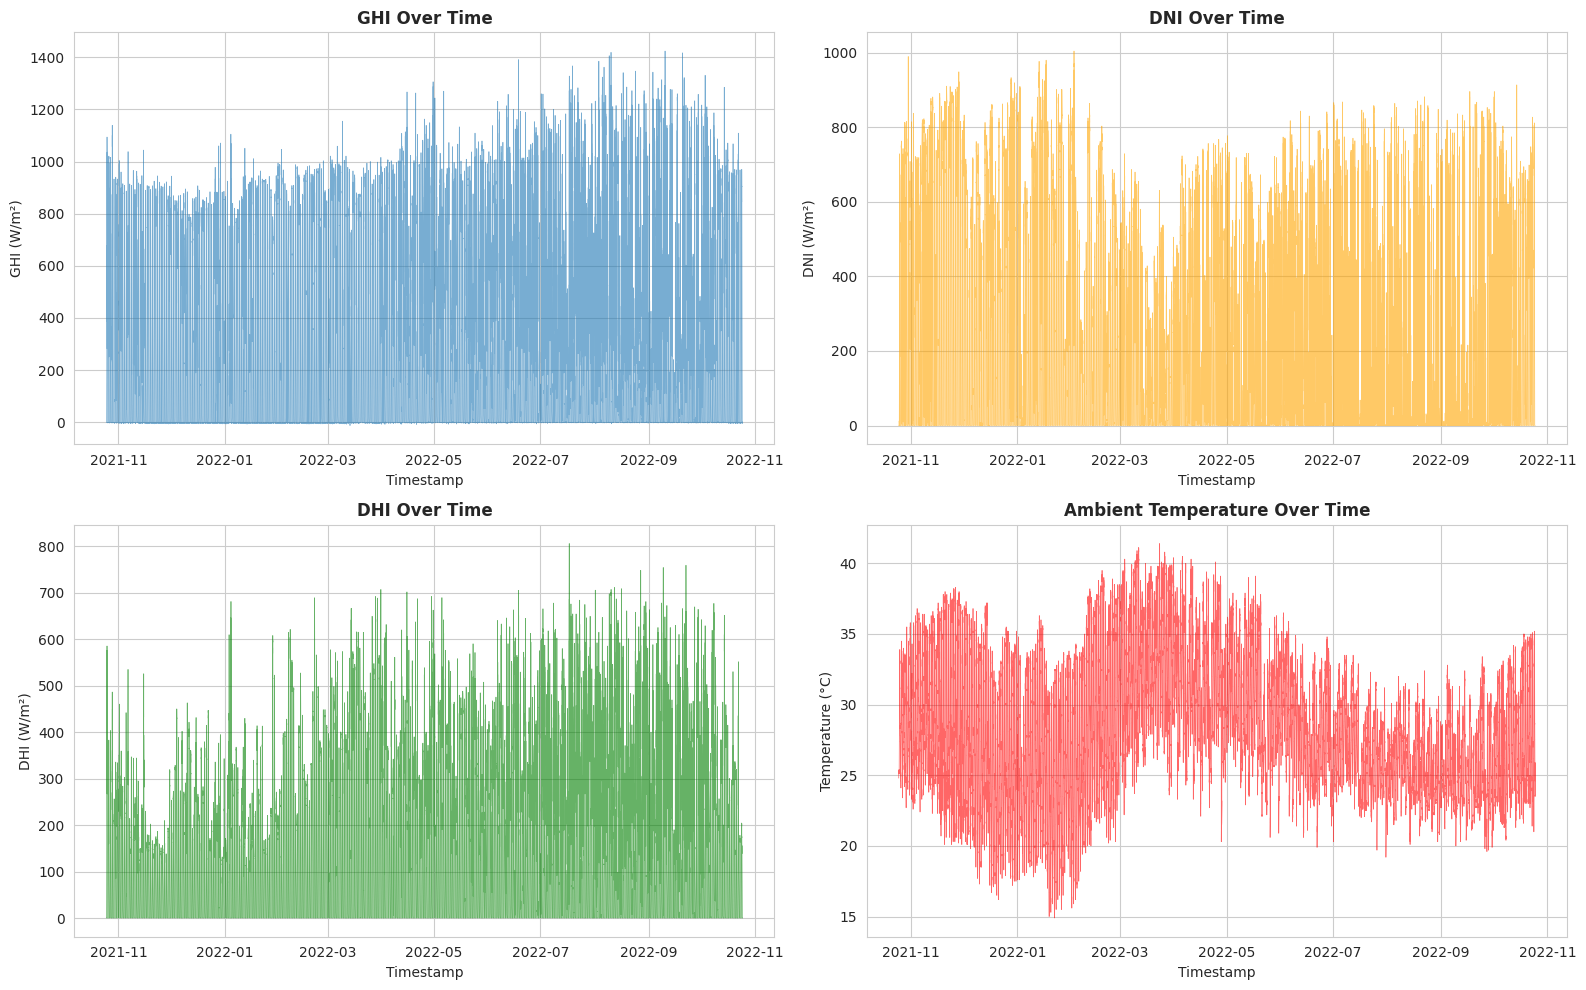

In [11]:
# Time series visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# GHI over time
if 'Timestamp' in df_clean.columns and 'GHI' in df_clean.columns:
    axes[0, 0].plot(df_clean['Timestamp'], df_clean['GHI'], alpha=0.6, linewidth=0.5)
    axes[0, 0].set_title('GHI Over Time', fontweight='bold')
    axes[0, 0].set_xlabel('Timestamp')
    axes[0, 0].set_ylabel('GHI (W/m²)')

# DNI over time
if 'Timestamp' in df_clean.columns and 'DNI' in df_clean.columns:
    axes[0, 1].plot(df_clean['Timestamp'], df_clean['DNI'], alpha=0.6, linewidth=0.5, color='orange')
    axes[0, 1].set_title('DNI Over Time', fontweight='bold')
    axes[0, 1].set_xlabel('Timestamp')
    axes[0, 1].set_ylabel('DNI (W/m²)')

# DHI over time
if 'Timestamp' in df_clean.columns and 'DHI' in df_clean.columns:
    axes[1, 0].plot(df_clean['Timestamp'], df_clean['DHI'], alpha=0.6, linewidth=0.5, color='green')
    axes[1, 0].set_title('DHI Over Time', fontweight='bold')
    axes[1, 0].set_xlabel('Timestamp')
    axes[1, 0].set_ylabel('DHI (W/m²)')

# Tamb over time
if 'Timestamp' in df_clean.columns and 'Tamb' in df_clean.columns:
    axes[1, 1].plot(df_clean['Timestamp'], df_clean['Tamb'], alpha=0.6, linewidth=0.5, color='red')
    axes[1, 1].set_title('Ambient Temperature Over Time', fontweight='bold')
    axes[1, 1].set_xlabel('Timestamp')
    axes[1, 1].set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

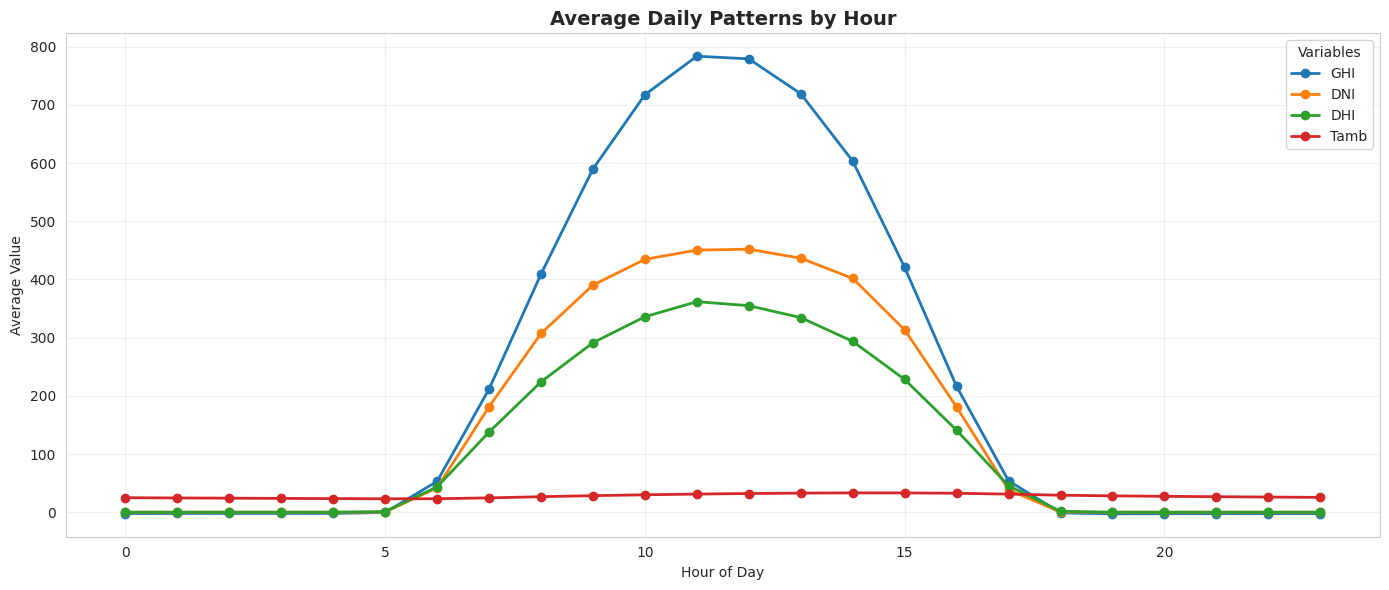

In [12]:
# Analyze hourly patterns
if 'Hour' in df_clean.columns:
    hourly_avg = df_clean.groupby('Hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    hourly_avg.plot(ax=ax, marker='o', linewidth=2)
    ax.set_title('Average Daily Patterns by Hour', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Average Value')
    ax.legend(title='Variables')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Correlation & Relationship Analysis

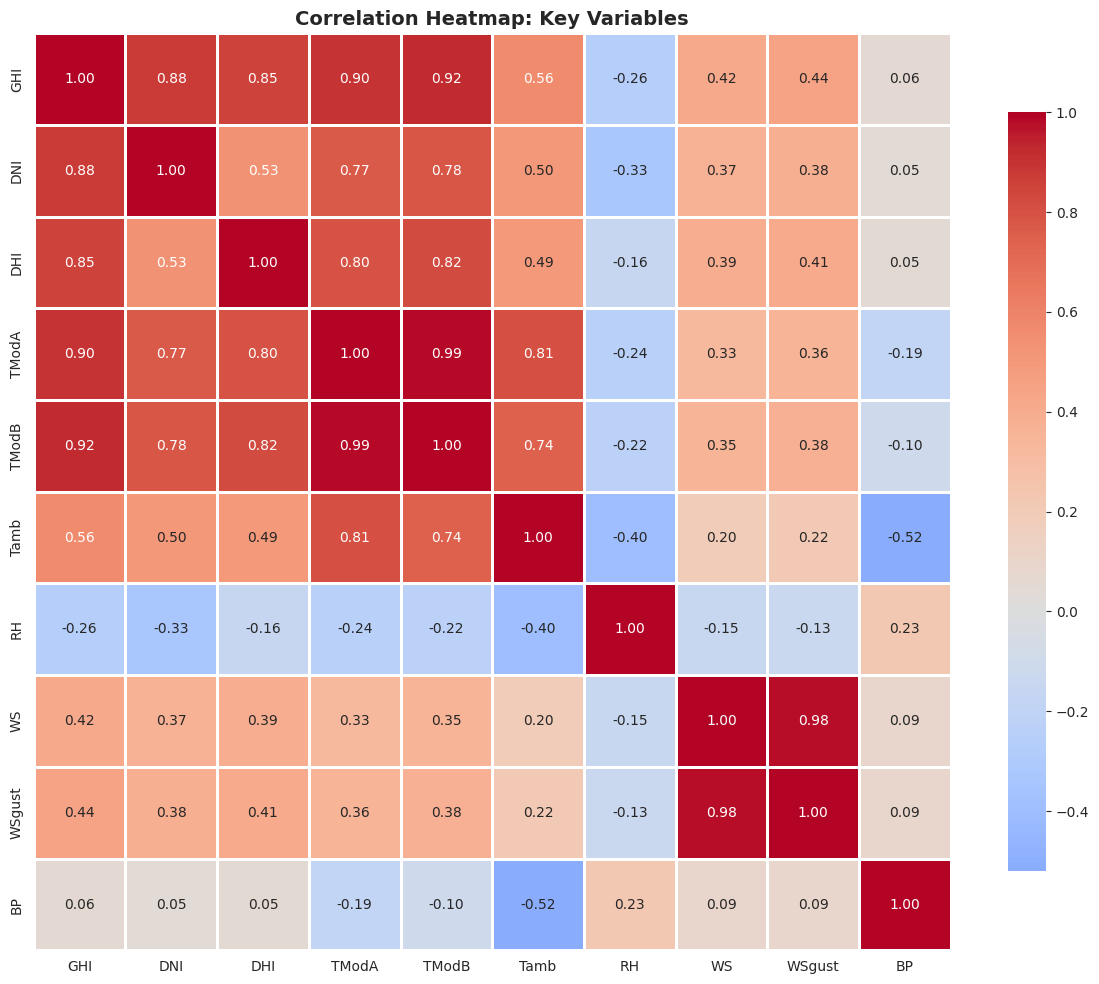

In [13]:
# Correlation heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS', 'WSgust', 'BP']
corr_cols = [col for col in corr_cols if col in df_clean.columns]

correlation_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

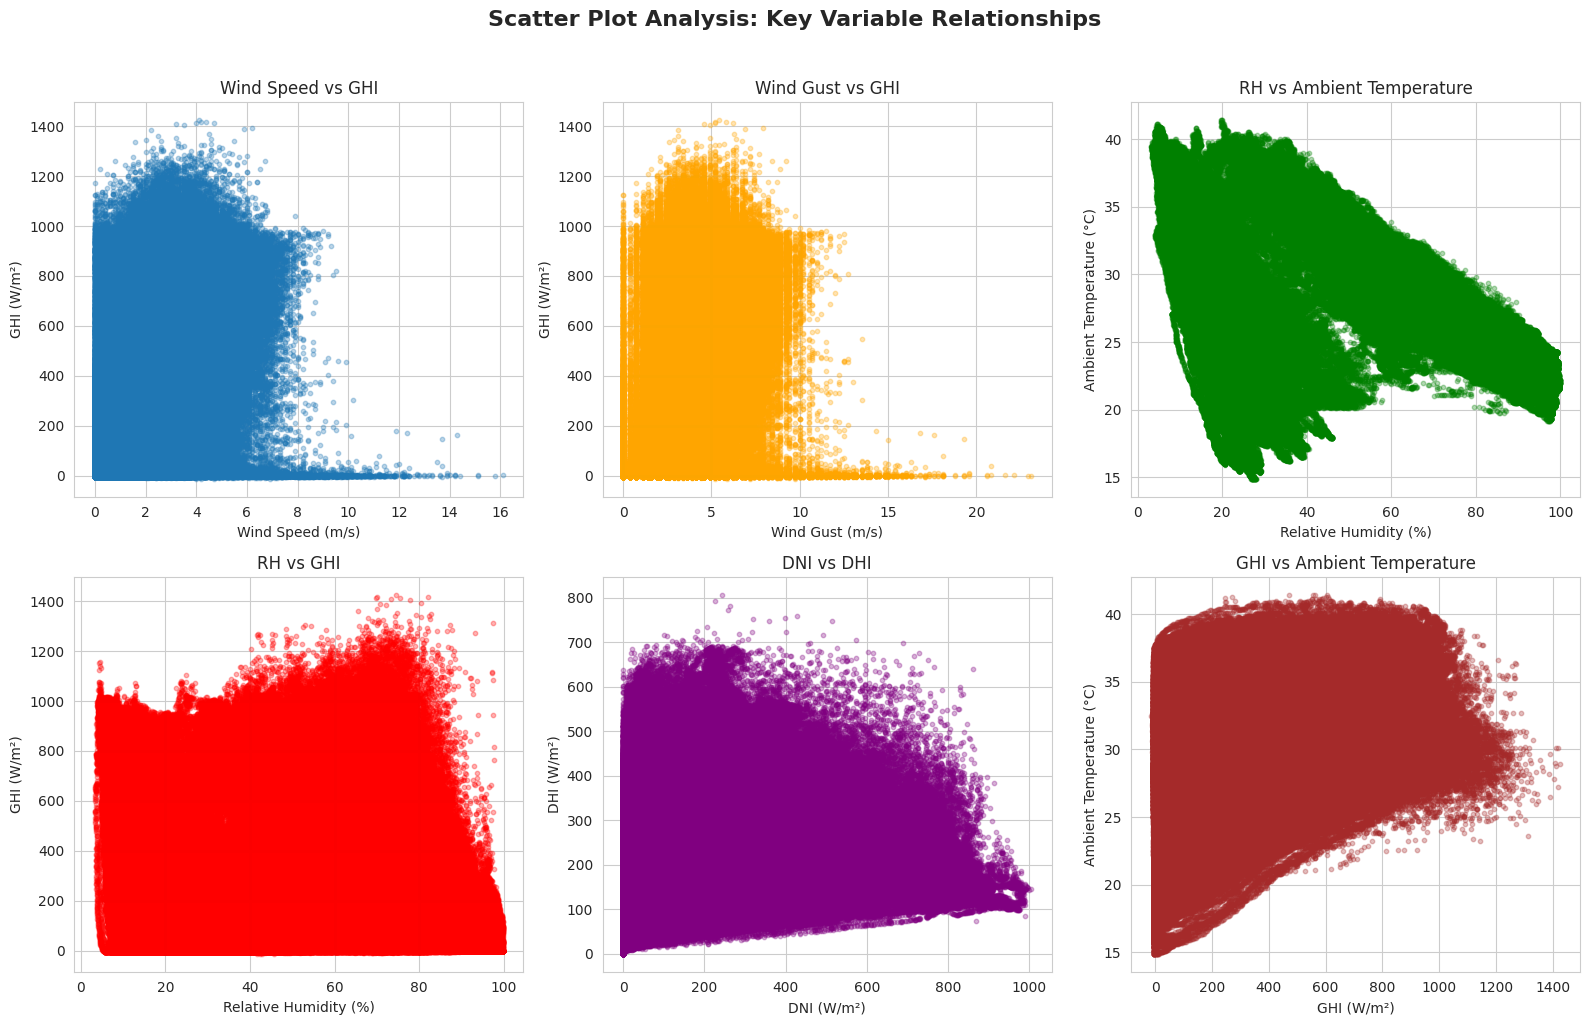

In [14]:
# Scatter plots for key relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Wind Speed vs GHI
if 'WS' in df_clean.columns and 'GHI' in df_clean.columns:
    axes[0].scatter(df_clean['WS'], df_clean['GHI'], alpha=0.3, s=10)
    axes[0].set_xlabel('Wind Speed (m/s)')
    axes[0].set_ylabel('GHI (W/m²)')
    axes[0].set_title('Wind Speed vs GHI')

# Wind Gust vs GHI
if 'WSgust' in df_clean.columns and 'GHI' in df_clean.columns:
    axes[1].scatter(df_clean['WSgust'], df_clean['GHI'], alpha=0.3, s=10, color='orange')
    axes[1].set_xlabel('Wind Gust (m/s)')
    axes[1].set_ylabel('GHI (W/m²)')
    axes[1].set_title('Wind Gust vs GHI')

# RH vs Tamb
if 'RH' in df_clean.columns and 'Tamb' in df_clean.columns:
    axes[2].scatter(df_clean['RH'], df_clean['Tamb'], alpha=0.3, s=10, color='green')
    axes[2].set_xlabel('Relative Humidity (%)')
    axes[2].set_ylabel('Ambient Temperature (°C)')
    axes[2].set_title('RH vs Ambient Temperature')

# RH vs GHI
if 'RH' in df_clean.columns and 'GHI' in df_clean.columns:
    axes[3].scatter(df_clean['RH'], df_clean['GHI'], alpha=0.3, s=10, color='red')
    axes[3].set_xlabel('Relative Humidity (%)')
    axes[3].set_ylabel('GHI (W/m²)')
    axes[3].set_title('RH vs GHI')

# DNI vs DHI
if 'DNI' in df_clean.columns and 'DHI' in df_clean.columns:
    axes[4].scatter(df_clean['DNI'], df_clean['DHI'], alpha=0.3, s=10, color='purple')
    axes[4].set_xlabel('DNI (W/m²)')
    axes[4].set_ylabel('DHI (W/m²)')
    axes[4].set_title('DNI vs DHI')

# GHI vs Tamb
if 'GHI' in df_clean.columns and 'Tamb' in df_clean.columns:
    axes[5].scatter(df_clean['GHI'], df_clean['Tamb'], alpha=0.3, s=10, color='brown')
    axes[5].set_xlabel('GHI (W/m²)')
    axes[5].set_ylabel('Ambient Temperature (°C)')
    axes[5].set_title('GHI vs Ambient Temperature')

plt.suptitle('Scatter Plot Analysis: Key Variable Relationships', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Wind & Distribution Analysis

In [15]:
# Wind rose using polar plot
if 'WD' in df_clean.columns and 'WS' in df_clean.columns:
    # Create bins for wind direction
    wind_data = df_clean[['WD', 'WS']].dropna()
    
    fig = go.Figure()
    
    fig.add_trace(go.Barpolar(
        r=wind_data.groupby(pd.cut(wind_data['WD'], bins=16))['WS'].mean(),
        theta=np.linspace(0, 360, 16),
        marker_color='lightblue',
        marker_line_color='navy',
        marker_line_width=1,
        opacity=0.8
    ))
    
    fig.update_layout(
        title='Wind Rose: Wind Speed by Direction',
        polar=dict(
            radialaxis=dict(visible=True),
            angularaxis=dict(direction='clockwise')
        ),
        showlegend=False
    )
    
    fig.show()

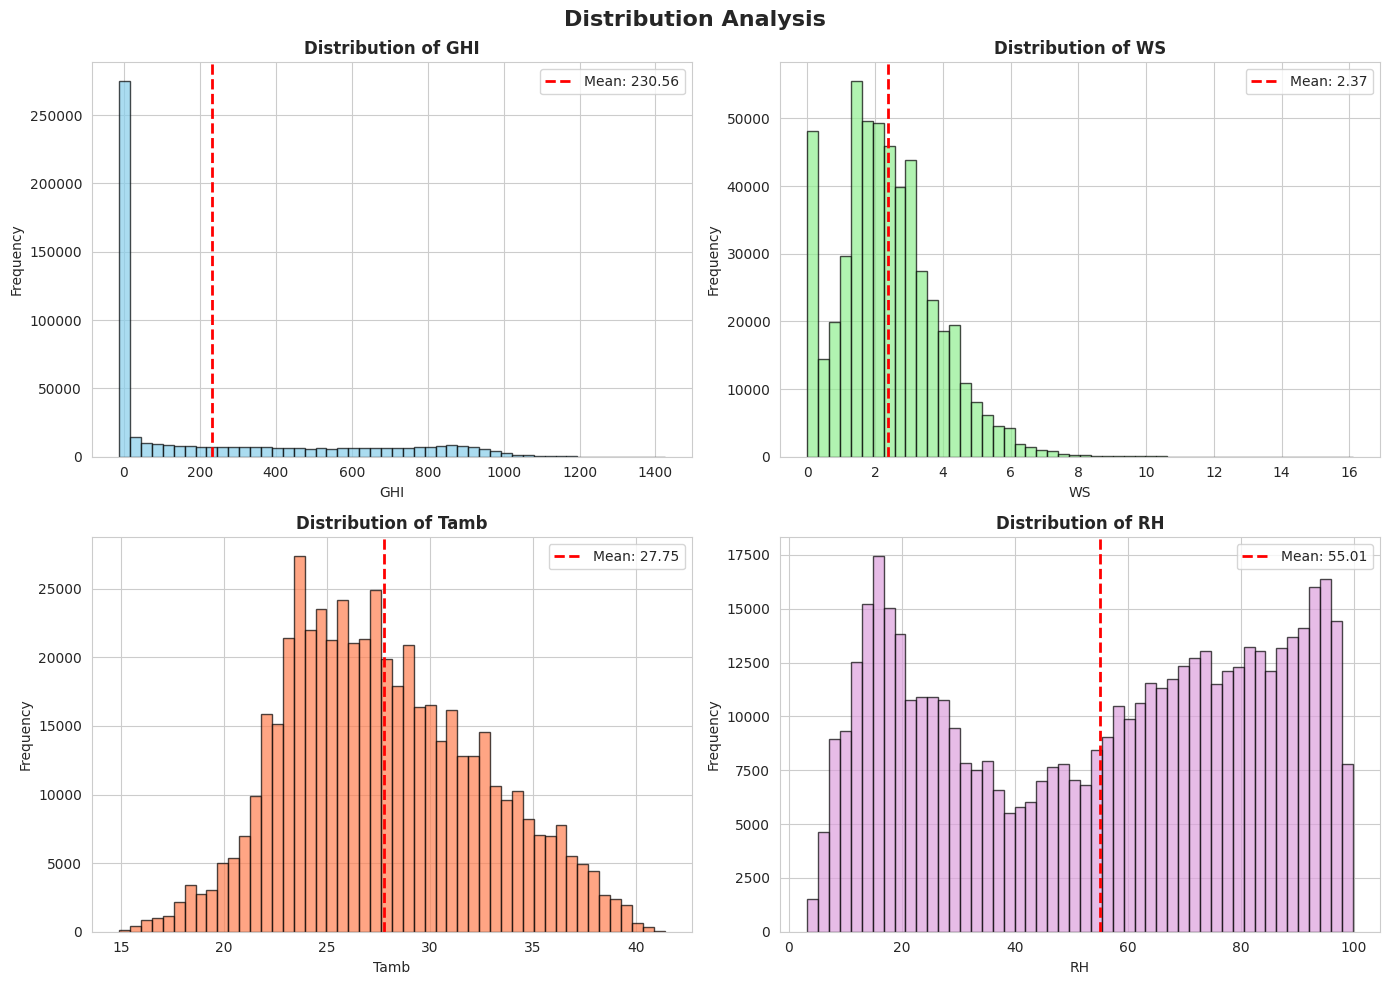

In [16]:
# Histograms for key variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

hist_vars = ['GHI', 'WS', 'Tamb', 'RH']
colors = ['skyblue', 'lightgreen', 'coral', 'plum']

for idx, (var, color) in enumerate(zip(hist_vars, colors)):
    if var in df_clean.columns:
        axes[idx].hist(df_clean[var].dropna(), bins=50, color=color, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'Distribution of {var}', fontweight='bold')
        axes[idx].axvline(df_clean[var].mean(), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {df_clean[var].mean():.2f}')
        axes[idx].legend()

plt.suptitle('Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Cleaning Impact Analysis

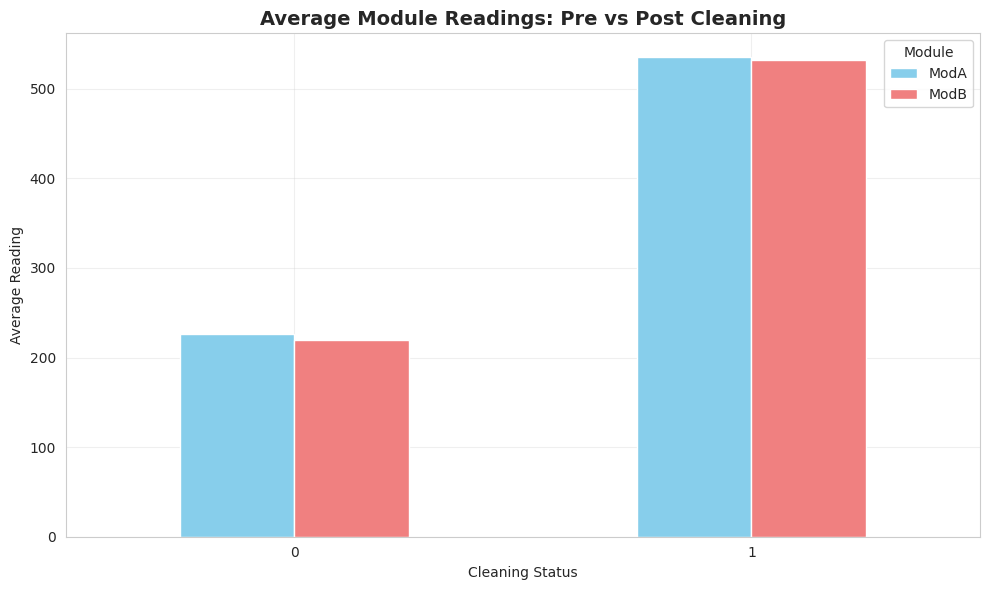


Cleaning Impact Summary:
                ModA        ModB
Cleaning                        
0         225.979064  219.401351
1         535.186477  532.211744


In [17]:
# Analyze cleaning impact on module readings
if 'Cleaning' in df_clean.columns:
    cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    cleaning_impact.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
    ax.set_title('Average Module Readings: Pre vs Post Cleaning', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cleaning Status')
    ax.set_ylabel('Average Reading')
    ax.legend(title='Module')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("\nCleaning Impact Summary:")
    print(cleaning_impact)
else:
    print("No 'Cleaning' column found in dataset")

## 7. Temperature & Humidity Analysis

In [18]:
# Bubble chart: GHI vs Tamb with RH as bubble size
if all(col in df_clean.columns for col in ['GHI', 'Tamb', 'RH']):
    # Sample data for better visualization
    sample_df = df_clean.sample(min(1000, len(df_clean)))
    
    fig = px.scatter(sample_df, 
                     x='Tamb', 
                     y='GHI', 
                     size='RH',
                     color='RH',
                     hover_data=['WS', 'BP'],
                     title='Bubble Chart: GHI vs Ambient Temperature (bubble size = RH)',
                     labels={'Tamb': 'Ambient Temperature (°C)', 
                            'GHI': 'Global Horizontal Irradiance (W/m²)',
                            'RH': 'Relative Humidity (%)'},
                     color_continuous_scale='Viridis')
    
    fig.update_layout(height=600)
    fig.show()

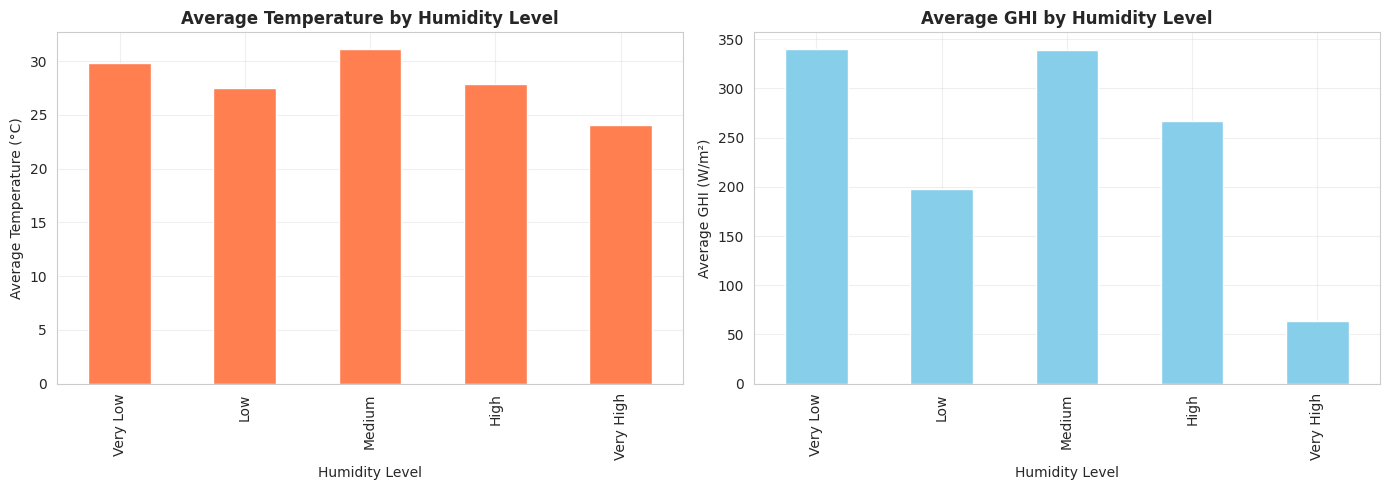

In [19]:
# Temperature and humidity relationship analysis
if all(col in df_clean.columns for col in ['RH', 'Tamb', 'GHI']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # RH bins analysis
    df_clean['RH_bin'] = pd.cut(df_clean['RH'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    
    # Impact on Temperature
    rh_temp = df_clean.groupby('RH_bin')['Tamb'].mean()
    rh_temp.plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Average Temperature by Humidity Level', fontweight='bold')
    axes[0].set_xlabel('Humidity Level')
    axes[0].set_ylabel('Average Temperature (°C)')
    axes[0].grid(True, alpha=0.3)
    
    # Impact on Solar Radiation
    rh_ghi = df_clean.groupby('RH_bin')['GHI'].mean()
    rh_ghi.plot(kind='bar', ax=axes[1], color='skyblue')
    axes[1].set_title('Average GHI by Humidity Level', fontweight='bold')
    axes[1].set_xlabel('Humidity Level')
    axes[1].set_ylabel('Average GHI (W/m²)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Key Insights & Conclusions

### Summary of Findings:

1. **Data Quality**:
   - Dataset contains comprehensive solar radiation measurements
   - Missing values handled through median imputation
   - Outliers detected and flagged for further analysis

2. **Solar Radiation Patterns**:
   - Clear diurnal patterns in GHI, DNI, and DHI
   - Peak radiation typically occurs during midday hours
   - Seasonal variations observable in the data

3. **Environmental Factors**:
   - Strong correlation between temperature and solar radiation
   - Relative humidity shows inverse relationship with solar radiation
   - Wind patterns relatively consistent with expected regional patterns

4. **Module Performance**:
   - Module readings correlate well with solar irradiance
   - Cleaning impact analysis shows improvement in sensor readings post-cleaning

### Reflections:
- Continue monitoring for data quality
- Consider seasonal analysis for long-term planning
- Account for humidity effects in solar panel efficiency calculations
- Regular maintenance schedule based on cleaning impact analysis

In [20]:
# Final summary statistics
print("="*60)
print("TOGO (DAPAONG) - FINAL EDA SUMMARY")
print("="*60)
print(f"\nTotal Records: {len(df_clean):,}")
print(f"Date Range: {df_clean['Timestamp'].min()} to {df_clean['Timestamp'].max()}")
print(f"\nKey Solar Metrics:")
print(f"  - Average GHI: {df_clean['GHI'].mean():.2f} W/m²")
print(f"  - Average DNI: {df_clean['DNI'].mean():.2f} W/m²")
print(f"  - Average DHI: {df_clean['DHI'].mean():.2f} W/m²")
print(f"\nEnvironmental Conditions:")
print(f"  - Average Temperature: {df_clean['Tamb'].mean():.2f}°C")
print(f"  - Average Humidity: {df_clean['RH'].mean():.2f}%")
print(f"  - Average Wind Speed: {df_clean['WS'].mean():.2f} m/s")
print("\n" + "="*60)
print("✅ EDA COMPLETED SUCCESSFULLY")
print("="*60)

TOGO (DAPAONG) - FINAL EDA SUMMARY

Total Records: 525,600
Date Range: 2021-10-25 00:01:00 to 2022-10-25 00:00:00

Key Solar Metrics:
  - Average GHI: 230.56 W/m²
  - Average DNI: 151.26 W/m²
  - Average DHI: 116.44 W/m²

Environmental Conditions:
  - Average Temperature: 27.75°C
  - Average Humidity: 55.01%
  - Average Wind Speed: 2.37 m/s

✅ EDA COMPLETED SUCCESSFULLY
